# Class conditioning

What the class label controls, probed on a trained checkpoint.

`UNet(num_classes=C)` embeds the label and adds it to `temb`, on the same footing
as `t`. The embedding has `C + 1` rows — index `C` is a null label, reserved and
left untrained so classifier-free guidance can reuse these weights. `Conditioned(net, y)`
freezes `y` back into the `(x, t) -> eps` interface the samplers call.

**Run the setup cell once, then any probe below on its own.**


## Setup


In [19]:
# --- setup: imports, checkpoint, samplers, helpers. Run this once. ---
%load_ext autoreload
%autoreload 2
# edits to unet.py / ddim.py land without a kernel restart. Structural changes to
# a class __init__ do NOT reach objects already built, so re-run this cell after
# those -- it rebuilds net from the checkpoint anyway.

from itertools import pairwise

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torchvision import datasets, transforms
from torchvision.utils import make_grid

from ddim import DDIMSampler
from forward_process import ForwardProcess
from unet import Conditioned, UNet
from utils import repo_root

dev = "cuda" if torch.cuda.is_available() else "cpu"

# run folders under artifacts/. RUN_UNCOND is the baseline for probe 4: same
# architecture and epoch count, trained with --num-classes 0
RUN = "cond_2026-09-09_11-42-46"
RUN_UNCOND = "first_2026-09-06_15-43-23"
ART = repo_root() / "artifacts"


def load(run):
    """Rebuild the net main.py saved. Returns (net, num_classes or None)."""
    ckpt = ART / run / "ckpt.pt"
    assert ckpt.exists(), (
        f"no checkpoint at {ckpt} -- runs: {sorted(p.name for p in ART.iterdir())}"
    )
    ck = torch.load(ckpt, map_location=dev)
    n = ck.get("num_classes") or None
    net = UNet(num_classes=n).to(dev)
    net.load_state_dict(ck["net"])
    net.eval()
    return net, n, ck["fp"]


net, C, fp_state = load(RUN)
assert C, f"{RUN} is unconditional -- train with: python main.py --num-classes 10"
net_uncond, c_uncond, fp_state_uncond = load(RUN_UNCOND)
assert c_uncond is None, f"{RUN_UNCOND} must be the unconditional baseline"

fp = ForwardProcess().to(dev)
fp.load_state_dict(fp_state)
# the two runs are only comparable if they shared a schedule
assert torch.equal(fp_state["betas"].to(dev), fp_state_uncond["betas"].to(dev))

# eta=0: sampling is a deterministic function of (x_T, y), which is what makes
# holding x_T fixed a controlled experiment
smp = DDIMSampler(fp, steps=50).to(dev)

_tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
ds = datasets.MNIST(root=repo_root() / "data", train=True, transform=_tf)
ds_test = datasets.MNIST(root=repo_root() / "data", train=False, transform=_tf)


def batch(dataset, n=128):
    """n images and their labels, on the device."""
    x = torch.stack([dataset[i][0] for i in range(n)]).to(dev)
    y = torch.tensor([dataset[i][1] for i in range(n)], device=dev)
    return x, y


@torch.no_grad()
def sample_from(xT, y):
    """DDIM from a GIVEN x_T instead of a fresh draw, so x_T is a variable you set."""
    x = xT
    for i in range(smp.steps):
        x = smp.step(Conditioned(net, y), x, i)
    return x


def show(x, nrow, title="", scale=0.4):
    """nrow is images PER row -- a column count, not a row count."""
    g = make_grid(x.cpu(), nrow=nrow, normalize=True, value_range=(-1, 1), padding=2)
    plt.figure(figsize=(nrow * scale, x.shape[0] / nrow * scale))
    plt.imshow(g.permute(1, 2, 0))
    plt.axis("off")
    if title:
        plt.title(title, fontsize=9)
    plt.show()


print(f"{RUN}  classes {C}   vs   {RUN_UNCOND}  unconditional   [{dev}]")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
cond_2026-09-09_11-42-46  classes 10   vs   first_2026-09-06_15-43-23  unconditional   [cuda]


## Probe 1 — same `x_T`, every label

`x_T` is the pure-noise image the sampler starts from: a real `[1, 28, 28]` tensor
of Gaussian numbers, not an RNG seed. Sampling walks it backwards to `x_0`.

**Shared `x_T`** means the same tensor is reused across a row:

```python
noise = torch.randn(8, 1, 28, 28)       # 8 distinct starting points
xT = noise.repeat_interleave(C, dim=0)  # each repeated C times, consecutively
y  = torch.arange(C).repeat(8)          # 0..9, 0..9, ...
```

Element `r*C + c` gets `noise[r]` and label `c`, so every cell in row `r` began
from the identical starting noise and the only thing changing along that row is `y`.

Why bother: with `eta=0` the output is a pure function of `(x_T, y)`. Fixing `x_T`
leaves exactly one variable, so any difference across a row is caused by the label
and nothing else. If each cell drew its own noise you could not tell a label effect
from a noise effect, and the grid would prove nothing about conditioning.


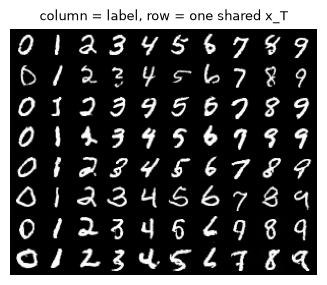

In [20]:
ROWS = 8
torch.manual_seed(7)
noise = torch.randn(ROWS, 1, 28, 28, device=dev)

xT = noise.repeat_interleave(C, dim=0)  # row r: one x_T, held fixed
y = torch.arange(C, device=dev).repeat(ROWS)  # col c: label c
show(sample_from(xT, y), nrow=C, title="column = label, row = one shared x_T")

**Columns hold identity.** Read down a column: different-looking 3s, all
unmistakably 3s. That is `y` doing its job.

**Rows hold style.** Read across a row: stroke weight and slant persist through
all ten digits. Since `y` was the only variable, that style must be carried by
`x_T` — it behaves like a latent style code. `x_T` decides _how_ the digit is
written, `y` decides _which_ digit. Nothing in the loss asked for that split; it
is a property of the learned map, and holding `x_T` fixed is what isolates it.


## Probe 2 — the reserved null label

Index `C` exists in the embedding but never received a gradient: every training
batch passes a real label in `0..C-1`. Adding it as one more column shows what an
untrained conditioning vector produces.


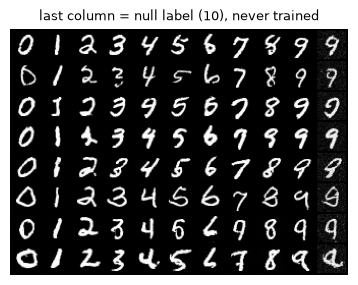

In [21]:
cols = C + 1  # ...plus the null label
xT = noise.repeat_interleave(cols, dim=0)
y = torch.arange(cols, device=dev).repeat(ROWS)
show(
    sample_from(xT, y),
    nrow=cols,
    title=f"last column = null label ({C}), never trained",
)

The null column is grey mush — correct, and useful. That row of `label_emb` is
still at its random init.

It is also why classifier-free guidance cannot skip label dropout. CFG computes

```
eps = eps_uncond + w * (eps_cond - eps_uncond)
```

If `eps_uncond` comes from an untrained null embedding it is noise, and the
formula extrapolates _away_ from noise, amplified by `w`. Training with p≈0.1
dropout is what turns this column into a real unconditional model. Re-running this
probe is the check: the null column should become plausible digits of no
particular class.


## Probe 3 — does `y` actually carry information?

The grids are read by eye. This is the number behind them: score the _same_ `x_t`
with the right label and with a wrong one. A label that is wired up but ignored —
added to `temb` and then normalised away, say — scores the two identically.


In [22]:
x0 = torch.stack([ds[i][0] for i in range(256)]).to(dev)
yc = torch.tensor([ds[i][1] for i in range(256)], device=dev)


def scored(lo, hi, draws=20):
    """eps-MSE with the true label vs a wrong one, for t drawn from [lo, hi)."""
    right = wrong = 0.0
    with torch.no_grad():
        for _ in range(draws):  # average over t and noise; one draw is far too noisy
            t = torch.randint(lo, hi, (x0.shape[0],), device=dev)
            eps = torch.randn_like(x0)
            xt = fp.q_sample(x0, t, eps)
            right += F.mse_loss(net(xt, t, yc), eps).item()
            wrong += F.mse_loss(net(xt, t, (yc + 1) % C), eps).item()
    return right / draws, wrong / draws


torch.manual_seed(0)
print(f"{'t range':>11}  {'right':>7}  {'wrong':>7}   penalty")
for lo in range(0, fp.T, 200):
    r, w = scored(lo, lo + 200)
    print(f"{lo:4d}-{lo + 200:<6d}  {r:7.4f}  {w:7.4f}   {w / r:5.2f}x")
r, w = scored(0, fp.T)
print(f"{'all t':>11}  {r:7.4f}  {w:7.4f}   {w / r:5.2f}x")

    t range    right    wrong   penalty
   0-200      0.0685   0.0703    1.03x
 200-400      0.0253   0.0366    1.44x
 400-600      0.0109   0.0223    2.04x
 600-800      0.0020   0.0034    1.73x
 800-1000     0.0003   0.0004    1.21x
      all t   0.0211   0.0266    1.26x


The penalty peaks in the **middle** of the chain, not at the end — which is not
the obvious guess.

- **low `t`** (~1.0x) — `x_t` is still legible, so the model reads the digit off
  its own input and the label is redundant. Lying about it costs nothing.
- **mid `t`** (the peak) — enough of `x0` is destroyed that identity has to come
  from `y`, but enough structure remains that getting it wrong is expensive. This
  is where conditioning does its work.
- **high `t`** — the penalty falls back. At `t≈900`, `sqrt(ᾱ)` is 0.016, so
  `x_t ≈ eps` and the best available prediction is close to _copy the input_ — a
  job no label can help or spoil much.

The `right` column has a shape of its own, which probe 4 takes apart.


## Probe 4 — where along `t` does the label actually help?

The eps-MSE profile across `t` is steep, but that is a property of the objective,
not of conditioning: an unconditional U-Net has the same shape. The
conditioning-specific question is the **difference** between two models that are
identical except for the label — `RUN` against `RUN_UNCOND`, same architecture,
same schedule, same 15 epochs, final training loss 0.0214 vs 0.0221.

Scored on held-out images, so neither model is being read back its own training set.


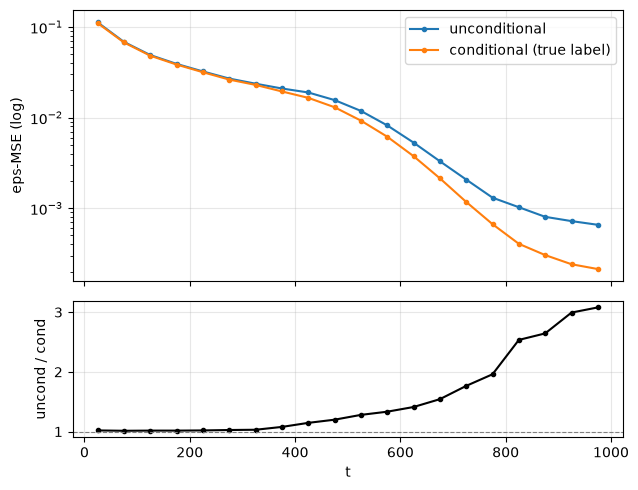

        t    uncond      cond   gain
   0-50      0.1127    0.1105    1.02x
 200-250     0.0323    0.0317    1.02x
 400-450     0.0190    0.0165    1.15x
 600-650     0.0053    0.0038    1.41x
 800-850     0.0010    0.0004    2.54x
     mean    0.0222    0.0210


In [23]:
EDGES = list(pairwise(range(0, fp.T + 1, 50)))
centers = [(lo + hi) / 2 for lo, hi in EDGES]


@torch.no_grad()
def eps_mse_by_t(model, x0, y, draws=10):
    """Average eps-MSE within each t bucket -- the per-epoch loss, unpooled.
    y=None drives the unconditional net through the same code path."""
    out = []
    for lo, hi in EDGES:
        s = 0.0
        for _ in range(draws):
            t = torch.randint(lo, hi, (x0.shape[0],), device=dev)
            eps = torch.randn_like(x0)
            s += F.mse_loss(model(fp.q_sample(x0, t, eps), t, y), eps).item()
        out.append(s / draws)
    return out


x0, y = batch(ds_test)
torch.manual_seed(0)
cond = eps_mse_by_t(net, x0, y)
torch.manual_seed(0)  # same t and noise draws, so the two are paired
uncond = eps_mse_by_t(net_uncond, x0, None)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(6.5, 5), sharex=True, height_ratios=[2, 1]
)
ax1.plot(centers, uncond, marker=".", label="unconditional")
ax1.plot(centers, cond, marker=".", label="conditional (true label)")
ax1.set_yscale("log")
ax1.set_ylabel("eps-MSE (log)")
ax1.legend()
ax1.grid(alpha=0.3)
ax2.plot(centers, [u / c for u, c in zip(uncond, cond)], marker=".", color="k")
ax2.axhline(1.0, ls="--", lw=0.8, color="grey")  # 1.0 = the label bought nothing
ax2.set_ylabel("uncond / cond")
ax2.set_xlabel("t")
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"{'t':>9}  {'uncond':>8}  {'cond':>8}   gain")
for j in range(0, len(centers), 4):
    u, c = uncond[j], cond[j]
    print(f"{EDGES[j][0]:4d}-{EDGES[j][1]:<4d}  {u:8.4f}  {c:8.4f}   {u / c:5.2f}x")
print(f"{'mean':>9}  {sum(uncond) / len(uncond):8.4f}  {sum(cond) / len(cond):8.4f}")

Both curves have the same steep shape — that is the eps objective, not the label.
The label shows up in the **gap**, and the gap widens monotonically with `t`:
about 1.0x below t=200, ~1.4x by t=600, ~2.5x past t=800.

That is the sensible place for it. At low `t` the digit is already legible in
`x_t`, so an unconditional net reads it off the input and the label tells it
nothing it did not have. As `t` rises `x_t` stops carrying identity, and `y`
becomes the only source of it — so that is where a model without labels starts
paying.

**Read the high-`t` ratios with care.** Those are two independent training runs,
so some of the gap is seed, not conditioning; and the absolute numbers there are
tiny (0.0010 vs 0.0004), which makes ratios fragile. The pooled means, 0.0222 vs
0.0210, match the final training losses of the two runs (0.0221, 0.0214) — a ~5%
edge that the per-epoch average almost entirely hides.

This probe gets rigorous for free after CFG. Training with label dropout gives
conditional _and_ unconditional predictions from **one** set of weights, so the
same comparison drops the second run and its seed with it.


## Probe 5 — the training grid, for contrast

`main.py` writes a grid every epoch with the opposite layout, and mixing the two
up is easy. Same helper, transposed meaning; the only difference is
`repeat_interleave` vs `repeat`.

|            | `main.py` grid                        | probes above                 |
| ---------- | ------------------------------------- | ---------------------------- |
| class runs | down the **rows**                     | across the **columns**       |
| noise      | independent per cell                  | **shared** `x_T` along a row |
| built with | `repeat_interleave`, `nrow=per_class` | `repeat`, `nrow=C`           |

It answers a different question: _does each class look right_, rather than _what
does the label control_.


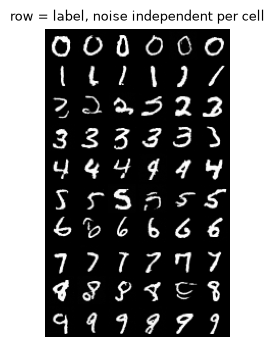

In [24]:
per_class = 6
y = torch.arange(C, device=dev).repeat_interleave(per_class)  # label-major
xT = torch.randn(y.shape[0], 1, 28, 28, device=dev)  # independent per cell
show(
    sample_from(xT, y), nrow=per_class, title="row = label, noise independent per cell"
)